In [1]:
import numpy as np
import matplotlib.pyplot as P

We want to solve the equation 
\begin{equation}
\partial_t \phi(\vec{x}) = \int w(\vec{x}-\vec{y})\phi(\vec{y})d^2y
\end{equation}
Where $w$ is a quenched anisotropic random function. 

We rewrite as follows:
\begin{equation}
\partial_t \phi(\vec{x}) = \int  w(\vec{x}_1)\phi(\vec{x}_2)\delta(\vec{x}-\vec{x}_1-\vec{x}_2) d^2x_1d^2x_2
\end{equation}
In Fourier space the convolution becomes a product and we write the equation has
\begin{equation}
\partial_t \phi(\vec{k}) = w(\vec{k})\phi(\vec{k})
\end{equation}
$w(\vec{x})$ is a noise such that 
\begin{equation}
\langle w(\vec{x}) \rangle = W
\end{equation}
where $W$ is a constant that does not depend on position. 
And its second moment as the form
\begin{equation}
\langle w(\vec{x})w(\vec{y})\rangle = G(\vec{r}) \quad\text{where}\quad \vec{r}=\vec{x}-\vec{y}
\end{equation}
and
\begin{equation}
G(\vec{r}) = G(r,\theta) = \exp(-r/\lambda)g(\theta)
\end{equation}
Then 
\begin{equation}
\langle w(\vec{k}) \rangle = W\int e^{i\vec{k}\cdot\vec{r}}d^2r = W\delta(\vec{k})
\end{equation}

The second moment of the noise in Fourier space takes the form
\begin{equation}
\langle w(\vec{q})w(\vec{p}) \rangle =\int G(\vec{r})e^{i\vec{q}\cdot\vec{r}}\delta(\vec{p}+\vec{q})d^2r
\end{equation}

Thus the strategy is as follows. First construct the function $G(r,\theta)$ in real space. Then
fourier transform to calculate $G(\vec{q})$. Then in Fourier space create a noise $w(\vec{q})$ that is Gaussian with zero mean and second moment at $\vec{q}$ proportional to $G(\vec{q})$.

We want a $G(\vec{r})$ that is anisotropic. It must decay (exponentially) fast in the radial direction. It must be periodic in the angle $\theta$ but we choose it not to be symmetric under the transformation $\theta$ to $\theta+\pi$  but nevertheless to be  even in $\theta$. Thus we choose  
\begin{equation}
G(r,\theta) = \exp(-r/\lambda)\sum_{2m+1}a_{2m+1}\cos[(2m+1)\theta]
\end{equation}
The anisotropy is coded into the coefficients $a_{2m+1}$. 
We show a plot of an example below:

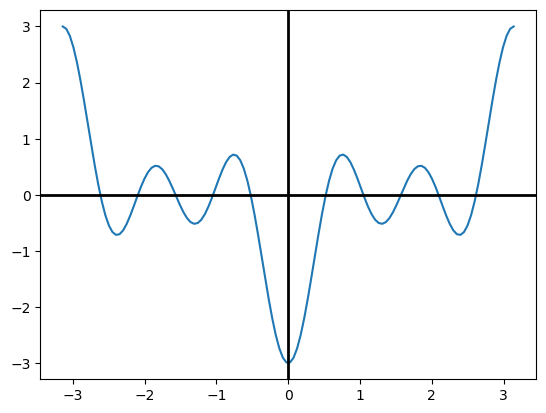

In [2]:
N=128
theta=np.linspace(0,2*np.pi,N)
coeffs=[0,1,0,1,0,1]
f_theta = np.cos(theta)+np.cos(3*theta)+np.cos(5*theta)
fig,ax=P.subplots()
ax.plot(theta-np.pi,f_theta)
#ax.plot(theta-np.pi,LegendreP2)
ax.axvline(x=0, color='black', linewidth=2)  # Vertical line at x=0
ax.axhline(y=0, color='black', linewidth=2)  # Horizontal line at y=0

In [4]:
def Greal(lamb,coeff,Phi=0.,Nr=128,Ntheta=256,rmax=np.pi):
    r = np.linspace(0, rmax, Nr)     
    theta = np.linspace(0, 2*np.pi, Ntheta)
    R, Theta = np.meshgrid(r, theta)
    g = np.zeros((Ntheta,Nr))
    G = np.zeros((Ntheta,Nr))
    xx = Theta+Phi
    m = 1
    for c in coeff:
        g = g+c*np.cos((2*m-1)*xx)
        m=m+1
    G = np.exp(-R / lamb)*g
    return Theta, R, G

Text(0.5, 1.0, 'Polar Contour Plot: G(r,θ) with  λ=1.5707963267948966')

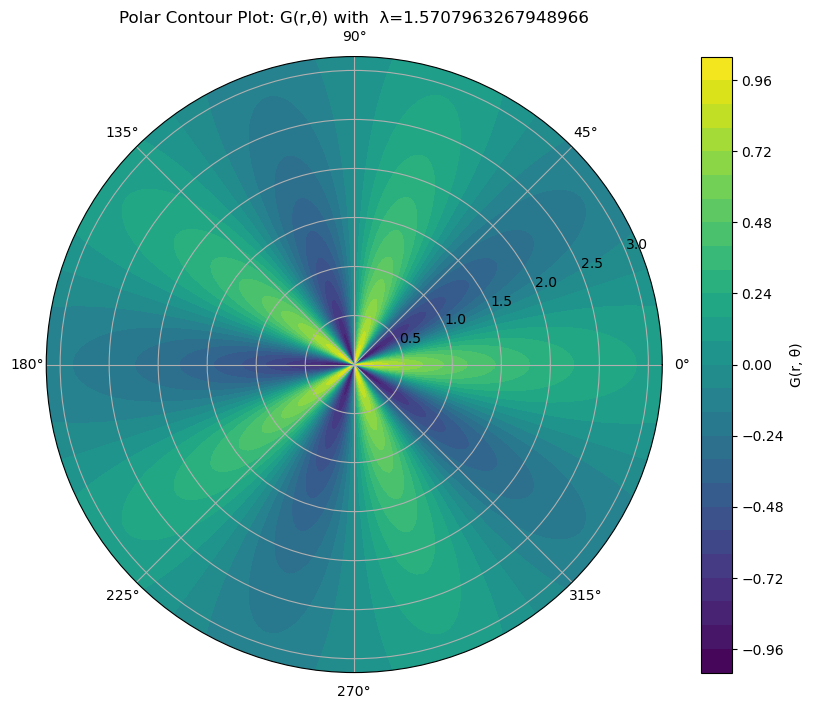

In [5]:
lamb=np.pi/2
coeff=[0,0,1]
Phi=0.
Theta,R,G=Greal(lamb,coeff,Phi)
fig, ax = P.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
contour = ax.contourf(Theta, R, G, levels=32, cmap='viridis')
P.colorbar(contour, ax=ax, label='G(r, θ)')
ax.set_title(f'Polar Contour Plot: G(r,θ) with  λ={lamb}')

In [6]:
def GrealC(lamb,coeff,Phi=0.,N=128,rmax=np.pi):
    x = np.linspace(-rmax, rmax, N)     
    y = np.linspace(-rmax, rmax, N)
    X, Y = np.meshgrid(x, y)
    g = np.zeros((N,N))
    G = np.zeros((N,N))
    R = np.sqrt(X*X+Y*Y)
    theta = np.arccos(X/R)+Phi
    m = 1
    for c in coeff:
        g = g+c*np.cos((2*m-1)*theta)
        m=m+1
    G = np.exp(-R / lamb)*g
    return X, Y, G

Text(0.5, 1.0, 'Contour Plot: G(x,y) with  λ=1.5707963267948966')

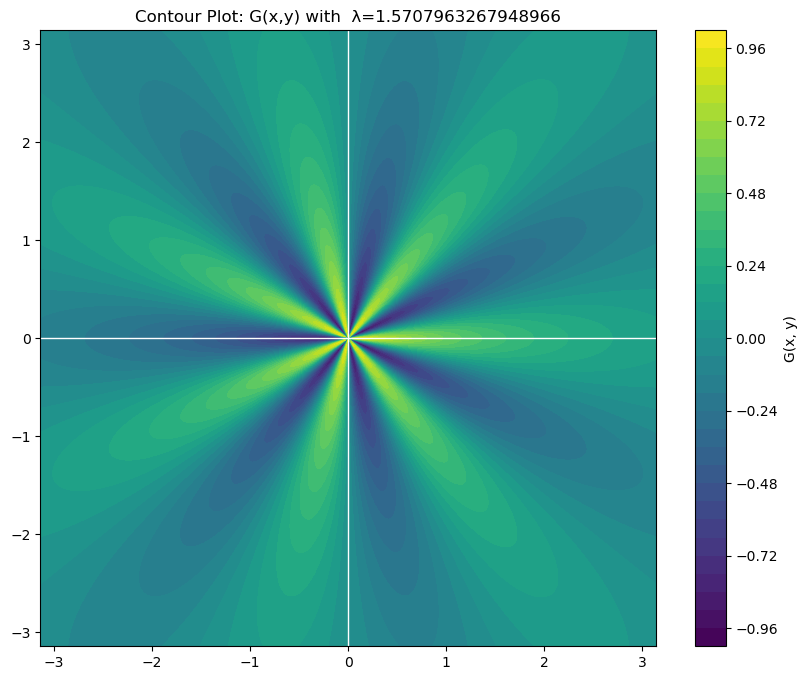

In [7]:
lamb=np.pi/2
coeff=[0,0,0,1]
Phi=0.
X,Y,GC=GrealC(lamb,coeff,Phi,N=512)
fig, ax = P.subplots(figsize=(10, 8))
ax.set_aspect("equal")
contour = ax.contourf(X, Y, GC, levels=32, cmap='viridis')
P.colorbar(contour, ax=ax, label='G(x, y)')
ax.axvline(x=0, color='white', linewidth=1)  # Vertical line at x=0
ax.axhline(y=0, color='white', linewidth=1)  # Horizontal line at y=0
ax.set_title(f'Contour Plot: G(x,y) with  λ={lamb}')

Text(0.5, 1.0, 'Polar Contour Plot: G(r,θ) with  λ=3.141592653589793')

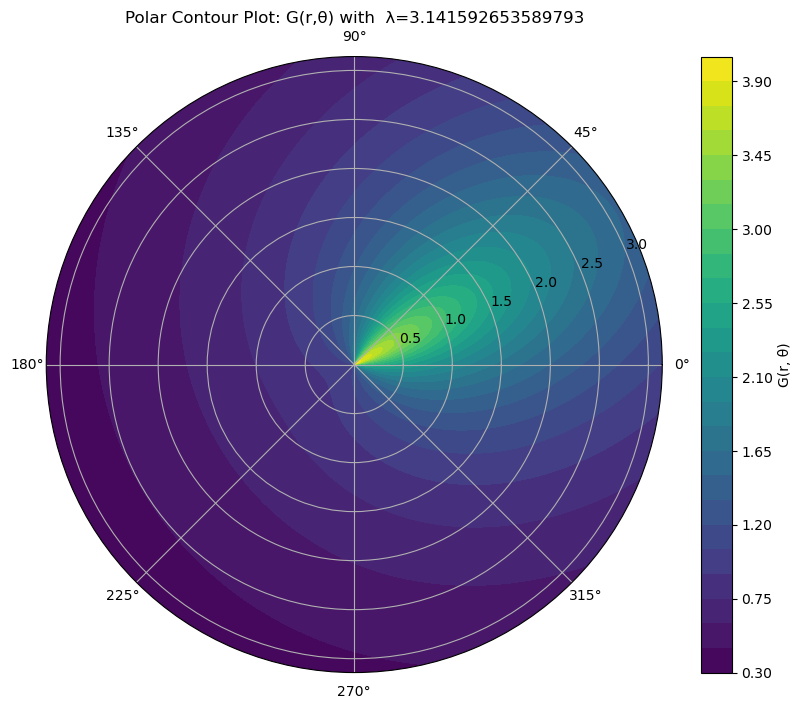

In [75]:
def Ganiso(lamb,Phi=0.,epsilon = 1.,Nr=128,Ntheta=256,rmax=np.pi):
    r = np.linspace(0, rmax, Nr)     
    theta = np.linspace(0, 2*np.pi, Ntheta)
    R, Theta = np.meshgrid(r, theta)
    g = np.zeros((Ntheta,Nr))
    G = np.zeros((Ntheta,Nr))
    psi = Theta/2+Phi/2
    g=(epsilon)/np.sqrt((np.cos(psi)**2+(epsilon**2)*np.sin(psi)**2))
    G = np.exp(-R / lamb)*g
    return Theta, R, G
lamb=np.pi
Phi=-np.pi/6
Theta,R,G=Ganiso(lamb,Phi,epsilon=4)
fig, ax = P.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
contour = ax.contourf(Theta, R, G, levels=32, cmap='viridis')
P.colorbar(contour, ax=ax, label='G(r, θ)')
ax.set_title(f'Polar Contour Plot: G(r,θ) with  λ={lamb}')

Text(0.5, 1.0, 'Contour Plot: G(x,y) with  λ=1.5707963267948966')

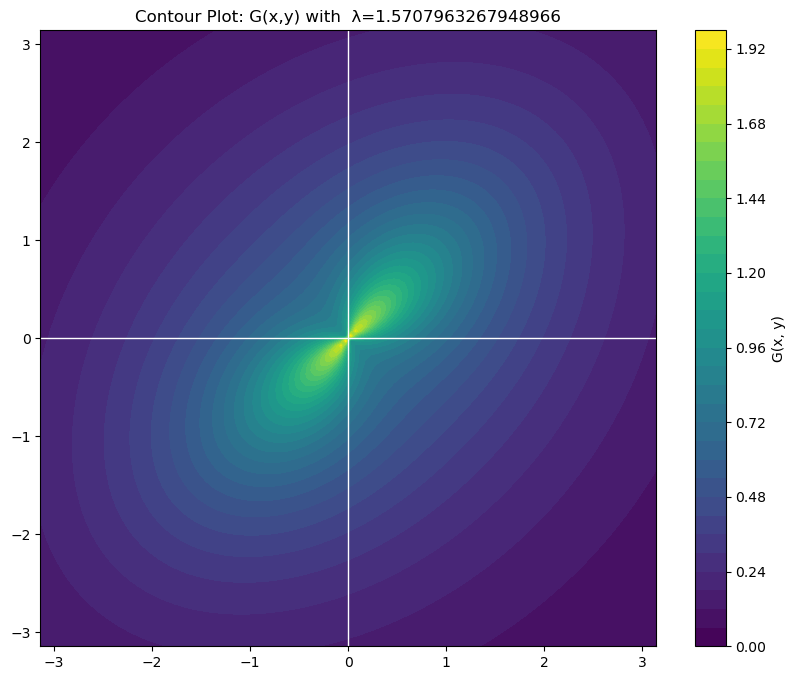

In [93]:
def GanisoC(lamb,Phi=0.,epsilon = 1, N=128,rmax=np.pi):
    x = np.linspace(-rmax, rmax, N)     
    y = np.linspace(-rmax, rmax, N)
    X, Y = np.meshgrid(x, y)
    g = np.zeros((N,N))
    G = np.zeros((N,N))
    R = np.sqrt(X*X+Y*Y)
    #theta = np.arccos(X/R)
    xrot = X*np.cos(Phi) + Y*np.sin(Phi)
    yrot = -X*np.sin(Phi) + Y*np.cos(Phi)
    g=(epsilon)*R/np.sqrt(xrot**2+(epsilon**2)*yrot**2)
    G = np.exp(-R / lamb)*g
    return X, Y, G
lamb=np.pi/2
Phi=np.pi/4
X,Y,GC=GanisoC(lamb,Phi,epsilon=2,N=128)
fig, ax = P.subplots(figsize=(10, 8))
ax.set_aspect("equal")
contour = ax.contourf(X, Y, GC, levels=32, cmap='viridis')
P.colorbar(contour, ax=ax, label='G(x, y)')
ax.axvline(x=0, color='white', linewidth=1)  # Vertical line at x=0
ax.axhline(y=0, color='white', linewidth=1)  # Horizontal line at y=0
ax.set_title(f'Contour Plot: G(x,y) with  λ={lamb}')

Next we want to Fourier transform to obtain G(\vec{q}). 

Text(0, 0.5, '$k_y$')

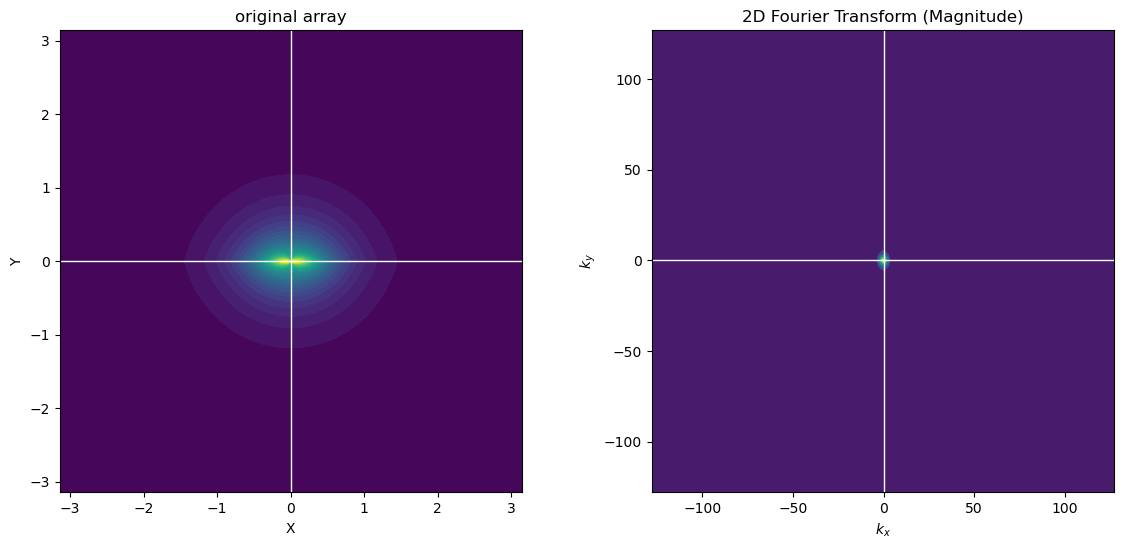

In [54]:
N=256
LL = 2*np.pi
x = np.linspace(-LL/2, LL/2, N)     
y = np.linspace(-LL/2, LL/2, N)
# Example 2D real array
lamb = np.pi/8
Phi=np.pi/4
X,Y,GC = GanisoC(lamb,Phi,epsilon=16,N=N,rmax=LL/2)
# Get array dimensions
Ny, Nx = GC.shape
# Plot
fig, axes = P.subplots(1, 2, figsize=(14, 6))
# Original array
axes[0].set_aspect("equal")
contour = axes[0].contourf(X, Y, GC, levels=32, cmap='viridis')
P.colorbar(contour, ax=ax, label='G(x, y)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].axvline(x=0, color='white', linewidth=1)  # Vertical line at x=0
axes[0].axhline(y=0, color='white', linewidth=1)  # Horizontal line at y=0
axes[0].set_title(f'original array')
# Compute 2D FFT
fft_result = np.fft.fft2(GC)
Ghat = np.fft.fftshift(fft_result)

# Generate frequency arrays
#deltar = N/
freq_y = np.fft.fftfreq(Ny,d=1./N)  # d is the sample spacing (adjust if your data has physical units)
freq_x = np.fft.fftfreq(Nx,d=1./N)

# Shift frequencies to match fftshift
freq_y_shifted = np.fft.fftshift(freq_y)
freq_x_shifted = np.fft.fftshift(freq_x)

# Create 2D meshgrid of frequencies
Freq_X, Freq_Y = np.meshgrid(freq_x_shifted, freq_y_shifted)

# Compute magnitude spectrum
magnitude = np.abs(Ghat)
magnitude_log = np.log(magnitude + 1e-10)


# Fourier magnitude with frequency axes
axes[1].set_aspect("equal")
#im = axes[1].imshow(magnitude_log, cmap='viridis', 
#                    extent=[Freq_X.min(), Freq_X.max(), Freq_Y.min(), Freq_Y.max()], 
#                    origin='lower')
contour = axes[1].contourf(Freq_X, Freq_Y, magnitude, cmap='viridis')
P.colorbar(contour, ax=ax, label=r'$\hat{G(k_x, k_y)}$')
axes[1].set_title('2D Fourier Transform (Magnitude)')
axes[1].axvline(x=0, color='white', linewidth=1)  # Vertical line at x=0
axes[1].axhline(y=0, color='white', linewidth=1)  # Horizontal line at y=0
axes[1].set_xlabel(r'$k_x$')
axes[1].set_ylabel(r'$k_y$')
#P.colorbar(im, ax=axes[1])

-20.371832715762604


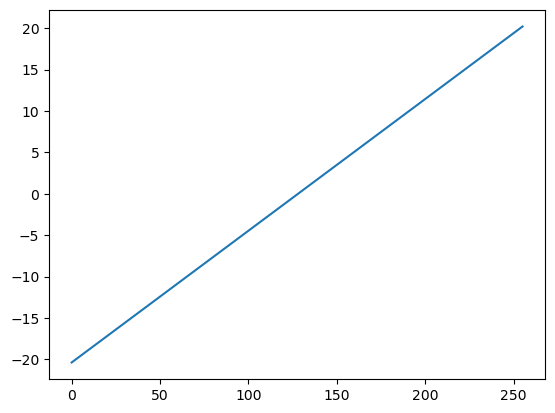

In [50]:
P.plot(freq_y_shifted)
print(freq_y_shifted.min())